In [1]:
import os
import glob
import pandas as pd
import numpy as np
import string
import tempfile
import csv
from matplotlib import pyplot as plt

# we will use Gensim to train our word embeddings
from gensim.test.utils import datapath
from gensim import utils
import gensim.models
from gensim.models.callbacks import CallbackAny2Vec

# for our 2D Word Embedding visual
from sklearn.decomposition import PCA

# we will use NKTK for lemmatization and stopword removal
import nltk
nltk.download('popular')
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('stopwords')

# this is for TF-IDF scores
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to

In [ ]:
def lemmatize_text(text):
    '''
    Lemmatizes the provided string and returns it.
    @param text : a string of unlemmatized text
    @return a lemmatized string
    '''
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word.lower()) for word in text.split()]
    return ' '.join(lemmatized_words)


def remove_stop_words(text):
    '''
    Removes stop words from the provided string and returns it.
    @param text : a string that contains stop words
    @return a string without stop words
    '''
    stop_words = set(stopwords.words('english'))
    filtered_sentence = [word for word in text.split() if word not in stop_words]
    return ' '.join(filtered_sentence)


def get_clean_odyssey_data_2():
    odyssey_df = pd.read_csv('odyssey.csv')
    for i in range(24):
        odyssey_df.loc[i,'content'] = odyssey_df['content'][i].lower()
        odyssey_df.loc[i,'content'] = remove_stop_words(odyssey_df['content'][i])
        odyssey_df.loc[i,'content'] = lemmatize_text(odyssey_df['content'][i])
    return odyssey_df

# Loads the text, removes stop words, and lemmatizes it in one pass.
corpus = get_clean_odyssey_data_2()


# Computational Method #1: TF-IDF Scores

In [3]:
def get_tfidf_by_book(target_word, odyssey_df):
    '''
    Computes the tfidf scores of the target word for each book in the Odyssey, 
    then adds those scores as a new column in the dataframe.

    @param target_word : the word to calculate TF-IDF for
    @param odyssey_df : a dataframe with the text of the odyssey in a column named 'content'
    @return the provided dataframe with an additional column named tfidf_targetword that contains the tf-idf scores

    Here is an example:
    - To call the function: odyssey_df = get_tfidf_by_book("home", odyssey_df)
    - To access the computed scores: odyssey_df['tfidf_home']
    '''
    # Initialize the vectorizer with the whole vocabulary
    vectorizer = TfidfVectorizer()

    # Fit and transform the 'content' column
    tfidf_matrix = vectorizer.fit_transform(odyssey_df['content'])

    # Get the index of the target word in the vocabulary
    try:
        word_index = vectorizer.vocabulary_[target_word]
        # Extract the TF-IDF scores for that word across all rows
        tfidf_scores = tfidf_matrix[:, word_index].toarray().flatten()
        # Add as a new column to the DataFrame
        odyssey_df[f'tfidf_{target_word}'] = tfidf_scores
    except KeyError:
        # Word not found in the vocabulary
        odyssey_df[f'tfidf_{target_word}'] = 0.0

    # Display the DataFrame
    #print(odyssey_df)
    return odyssey_df

    tfidf_host  tfidf_home  tfidf_feast  tfidf_gift  tfidf_alcinous
0     0.048000    0.285936     0.233161    0.149240        0.000000
1     0.048731    0.129019     0.157809    0.075757        0.000000
2     0.238735    0.158016     0.257702    0.000000        0.000000
3     0.112198    0.185657     0.181668    0.109014        0.000000
4     0.000000    0.082133     0.000000    0.000000        0.000000
5     0.000000    0.109932     0.000000    0.129099        0.583033
6     0.000000    0.117223     0.143381    0.091774        1.865113
7     0.140273    0.116056     0.141954    0.381615        1.371719
8     0.038311    0.152147     0.000000    0.208453        0.057637
9     0.036997    0.122439     0.089856    0.086272        0.000000
10    0.173416    0.091826     0.112316    0.188713        0.260897
11    0.000000    0.027845     0.000000    0.000000        0.000000
12    0.000000    0.243378     0.074422    0.214359        0.760636
13    0.123172    0.135877     0.066479    0.063

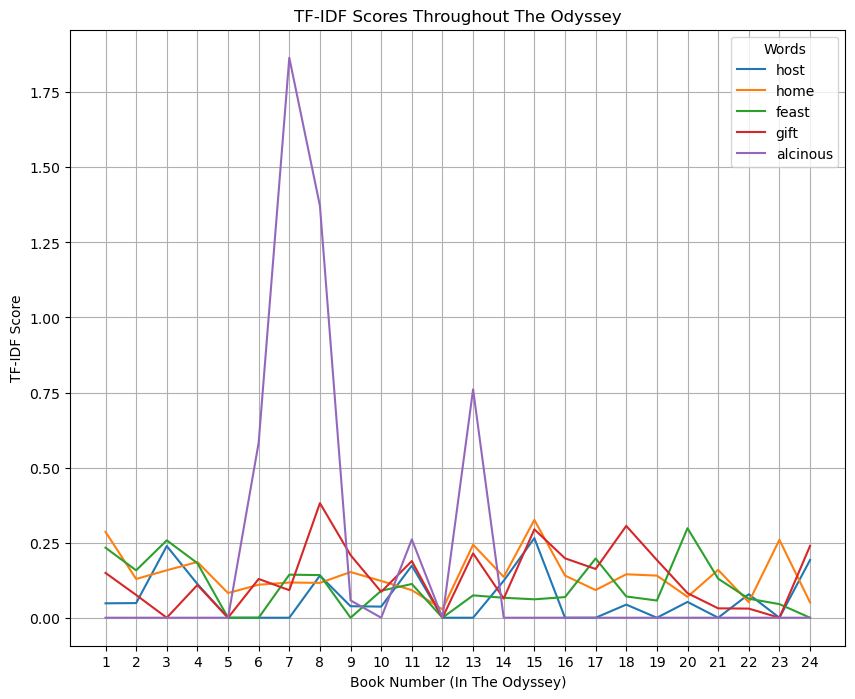

In [4]:
# Alcinous vs hospitable words

od = get_clean_odyssey_data_2()
df_host = get_tfidf_by_book("host", od)
df_home = get_tfidf_by_book("home", od)
df_feast = get_tfidf_by_book("feast", od)
df_gift = get_tfidf_by_book("gift", od)
df_alcinous = get_tfidf_by_book("alcinous", od)

all_dfs = df_host + df_home + df_feast + df_gift + df_alcinous


subset = all_dfs[['tfidf_host','tfidf_home','tfidf_feast','tfidf_gift','tfidf_alcinous']]
print(subset)

ax = subset.plot(figsize=(10,8))

ax.set_xlabel('Book Number (In The Odyssey)')
ax.set_ylabel('TF-IDF Score')
ax.set_title('TF-IDF Scores Throughout The Odyssey')
ax.grid(True)
ax.set_xticks(range(24))
ax.set_xticklabels(range(1, 25))

handles, labels = ax.get_legend_handles_labels()
new_labels = [label.replace('tfidf_', '') for label in labels]
ax.legend(handles, new_labels, title='Words')

plt.show()

    tfidf_host  tfidf_home  tfidf_feast  tfidf_gift  tfidf_eumaeus
0     0.048000    0.285936     0.233161    0.149240       0.000000
1     0.048731    0.129019     0.157809    0.075757       0.000000
2     0.238735    0.158016     0.257702    0.000000       0.000000
3     0.112198    0.185657     0.181668    0.109014       0.000000
4     0.000000    0.082133     0.000000    0.000000       0.000000
5     0.000000    0.109932     0.000000    0.129099       0.000000
6     0.000000    0.117223     0.143381    0.091774       0.000000
7     0.140273    0.116056     0.141954    0.381615       0.000000
8     0.038311    0.152147     0.000000    0.208453       0.000000
9     0.036997    0.122439     0.089856    0.086272       0.000000
10    0.173416    0.091826     0.112316    0.188713       0.000000
11    0.000000    0.027845     0.000000    0.000000       0.000000
12    0.000000    0.243378     0.074422    0.214359       0.000000
13    0.123172    0.135877     0.066479    0.063827       0.46

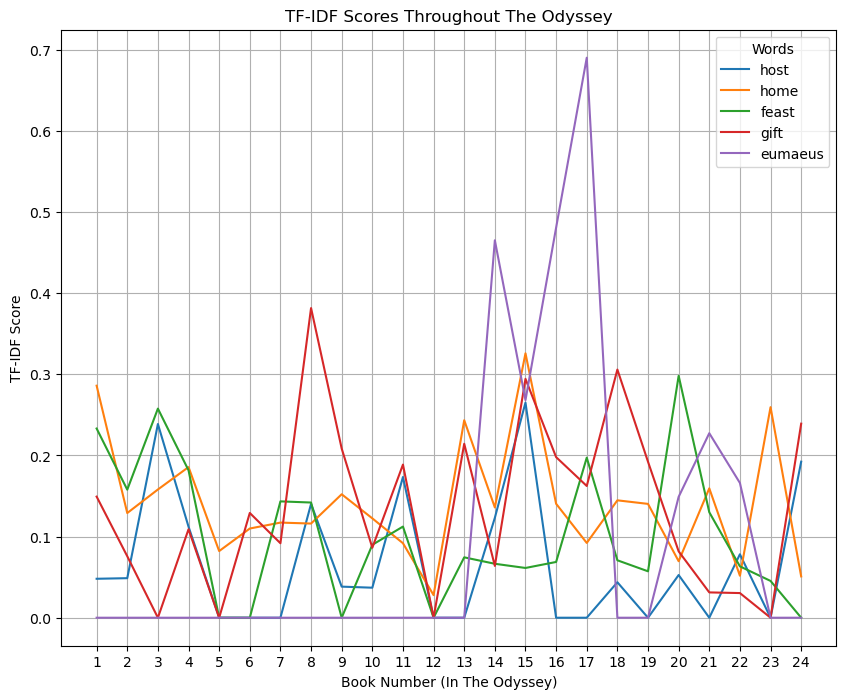

In [5]:
# Eumaeus vs hospitable words

od = get_clean_odyssey_data_2()
df_host = get_tfidf_by_book("host", od)
df_home = get_tfidf_by_book("home", od)
df_feast = get_tfidf_by_book("feast", od)
df_gift = get_tfidf_by_book("gift", od)
df_eumaeus = get_tfidf_by_book("eumaeus", od)

all_dfs = df_host + df_home + df_feast + df_gift + df_eumaeus


subset = all_dfs[['tfidf_host','tfidf_home','tfidf_feast','tfidf_gift','tfidf_eumaeus']]
print(subset)

ax = subset.plot(figsize=(10,8))

ax.set_xlabel('Book Number (In The Odyssey)')
ax.set_ylabel('TF-IDF Score')
ax.set_title('TF-IDF Scores Throughout The Odyssey')
ax.grid(True)
ax.set_xticks(range(24))
ax.set_xticklabels(range(1, 25))

handles, labels = ax.get_legend_handles_labels()
new_labels = [label.replace('tfidf_', '') for label in labels]
ax.legend(handles, new_labels, title='Words')

plt.show()


    tfidf_host  tfidf_home  tfidf_feast  tfidf_gift  tfidf_nestor
0     0.048000    0.285936     0.233161    0.149240      0.067971
1     0.048731    0.129019     0.157809    0.075757      0.000000
2     0.238735    0.158016     0.257702    0.000000      1.464950
3     0.112198    0.185657     0.181668    0.109014      0.397202
4     0.000000    0.082133     0.000000    0.000000      0.000000
5     0.000000    0.109932     0.000000    0.129099      0.000000
6     0.000000    0.117223     0.143381    0.091774      0.000000
7     0.140273    0.116056     0.141954    0.381615      0.000000
8     0.038311    0.152147     0.000000    0.208453      0.000000
9     0.036997    0.122439     0.089856    0.086272      0.000000
10    0.173416    0.091826     0.112316    0.188713      0.098228
11    0.000000    0.027845     0.000000    0.000000      0.000000
12    0.000000    0.243378     0.074422    0.214359      0.000000
13    0.123172    0.135877     0.066479    0.063827      0.000000
14    0.26

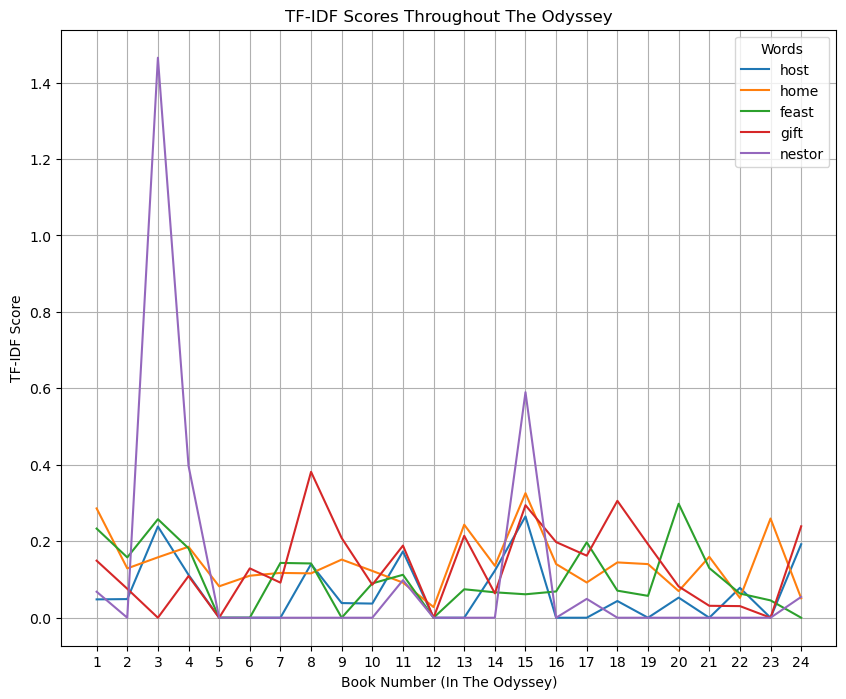

In [6]:
# Nestor vs hospitable words

od = get_clean_odyssey_data_2()
df_host = get_tfidf_by_book("host", od)
df_home = get_tfidf_by_book("home", od)
df_feast = get_tfidf_by_book("feast", od)
df_gift = get_tfidf_by_book("gift", od)
df_nestor = get_tfidf_by_book("nestor", od)

all_dfs = df_host + df_home + df_feast + df_gift + df_nestor 


subset = all_dfs[['tfidf_host','tfidf_home','tfidf_feast','tfidf_gift','tfidf_nestor']]
print(subset)

ax = subset.plot(figsize=(10,8))

ax.set_xlabel('Book Number (In The Odyssey)')
ax.set_ylabel('TF-IDF Score')
ax.set_title('TF-IDF Scores Throughout The Odyssey')
ax.grid(True)
ax.set_xticks(range(24))
ax.set_xticklabels(range(1, 25))

handles, labels = ax.get_legend_handles_labels()
new_labels = [label.replace('tfidf_', '') for label in labels]
ax.legend(handles, new_labels, title='Words')

plt.show()


    tfidf_host  tfidf_home  tfidf_feast  tfidf_gift  tfidf_menelaus
0     0.048000    0.285936     0.233161    0.149240        0.057854
1     0.048731    0.129019     0.157809    0.075757        0.000000
2     0.238735    0.158016     0.257702    0.000000        0.479574
3     0.112198    0.185657     0.181668    0.109014        0.845196
4     0.000000    0.082133     0.000000    0.000000        0.000000
5     0.000000    0.109932     0.000000    0.129099        0.000000
6     0.000000    0.117223     0.143381    0.091774        0.000000
7     0.140273    0.116056     0.141954    0.381615        0.042267
8     0.038311    0.152147     0.000000    0.208453        0.000000
9     0.036997    0.122439     0.089856    0.086272        0.000000
10    0.173416    0.091826     0.112316    0.188713        0.041803
11    0.000000    0.027845     0.000000    0.000000        0.000000
12    0.000000    0.243378     0.074422    0.214359        0.055398
13    0.123172    0.135877     0.066479    0.063

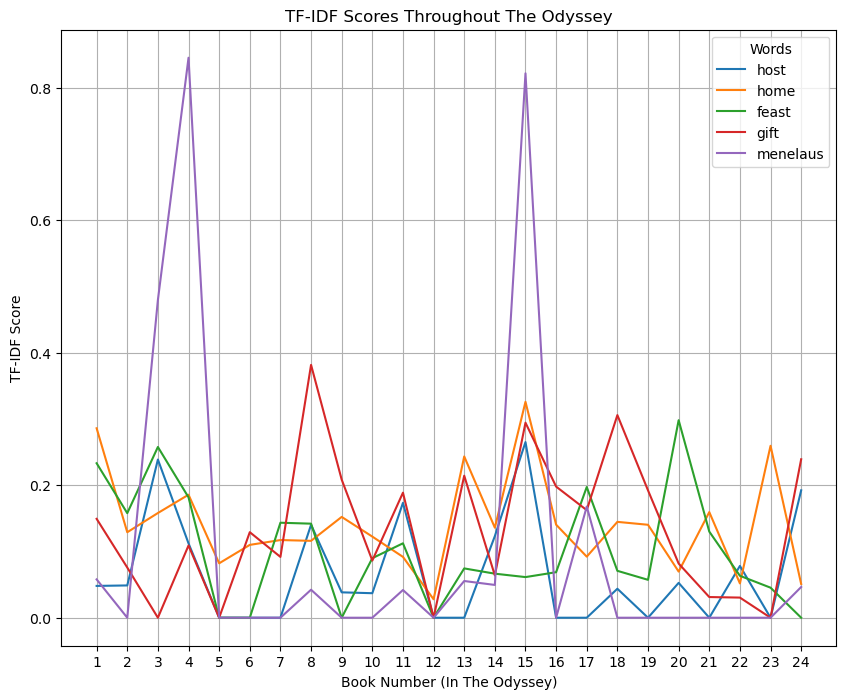

In [7]:
# Menelaus vs hospitable words

od = get_clean_odyssey_data_2()
df_host = get_tfidf_by_book("host", od)
df_home = get_tfidf_by_book("home", od)
df_feast = get_tfidf_by_book("feast", od)
df_gift = get_tfidf_by_book("gift", od)
df_menelaus = get_tfidf_by_book("menelaus", od)

all_dfs = df_host + df_home + df_feast + df_gift + df_menelaus


subset = all_dfs[['tfidf_host','tfidf_home','tfidf_feast','tfidf_gift','tfidf_menelaus']]
print(subset)

ax = subset.plot(figsize=(10,8))

ax.set_xlabel('Book Number (In The Odyssey)')
ax.set_ylabel('TF-IDF Score')
ax.set_title('TF-IDF Scores Throughout The Odyssey')
ax.grid(True)
ax.set_xticks(range(24))
ax.set_xticklabels(range(1, 25))

handles, labels = ax.get_legend_handles_labels()
new_labels = [label.replace('tfidf_', '') for label in labels]
ax.legend(handles, new_labels, title='Words')

plt.show()


# Computational Method #2: Word Embeddings

In [8]:
class callback(CallbackAny2Vec):
    '''Callback to print loss after each epoch.
       You should stop training your word embeddings when loss stops significantly improving. 
       You will probably need to test that out! 
       Training time selection is an art, not a science.    
    '''

    def __init__(self):
        self.epoch = 0
        self.last = 0
        self.first_run = True

    def on_epoch_end(self, model):
        if self.first_run:
            self.last = model.get_latest_training_loss()
            self.first_run = False
            print('Loss after epoch {}: {}'.format(self.epoch, self.last))
            self.epoch += 1
        else:
            loss = model.get_latest_training_loss()
            converted = loss - self.last
            print('Loss after epoch {}: {}'.format(self.epoch, converted))
            self.epoch += 1
            self.last = loss

def preprocessing(corpus):
    '''
    Preprocesses the raw corpus by extracting each text in the corpus and placing it in its own entry in a new list.
    Each text (each entry in the list) is then split by whitespace
    @param corpus: made up of texts organized in a table
    @return a list consisting of each text
    '''
    training_data = []
    for ind,row in corpus.iterrows():
      training_data.append(row['content'].split(" "))
    return training_data

def train_skipgram(training_data):
    '''
    Creates a skip-gram model using Word2Vec trained on the parameter training_data for num_epochs. 
    It then computes the training loss after each epoch and saves the trained model as a file named after the number of epochs.
    @param preprocessed training data
    @return a trained skip-gram Word2Vec model
    '''
    num_epochs=100
    model = gensim.models.Word2Vec(epochs=num_epochs, sg=1, sentences=training_data, min_count=5, compute_loss=True, callbacks=[callback()])
    model.save('models/gensim-sg-model-' + str(num_epochs))
    print("Model saved: " + 'models/gensim-sg-model-' + str(num_epochs))
    return model

def train_cbow(training_data):
    '''
    Creates a CBOW model using Word2Vec trained on the parameter training_data for num_epochs.
    It then computes the training loss after each epoch and saves the training model as a file named after the number of epochs.
    @param preprocessed training data
    @return a trained CBOW Word2Vec model
    '''
    num_epochs=50
    model = gensim.models.Word2Vec(epochs=num_epochs, sg=0, sentences=training_data, min_count=10, compute_loss=True, callbacks=[callback()])
    model.save('models/gensim-cbow-model-' + str(num_epochs))
    print("Model saved: " + 'models/gensim-cbow-model-' + str(num_epochs))
    return model

def get_ten_closest(model, target_word):
    '''
    Uses a trained model and finds the closest ten words to the input target_word.
    @param trained Word2Vec model; target word
    @return the 10 closest words to target_word and each of their similarity scores based on the model
    '''
    options_fields = ['word', 'sim01word', 'sim01score', 'sim02word', 'sim02score', 'sim03word', 'sim03score',
                      'sim04word', 'sim04score', 'sim05word', 'sim05score', 'sim06word', 'sim06score',
                      'sim07word', 'sim07score', 'sim08word', 'sim08score', 'sim09word', 'sim09score',
                      'sim10word', 'sim10score']
    topten = model.wv.most_similar(positive=[target_word], topn=10)
    row = [target_word]
    print("Top ten most similar words to ", target_word)
    i = 1
    for pair in topten:
      printout = str(i) + ". " + pair[0] + ", distance: " + str(pair[1])
      row.append(pair[0])
      row.append(pair[1])
      print(printout)
      i += 1

def get_ten_farthest(model, target_word):
    '''
    Uses a trained model and finds the ten words that are least similar to the input target_word.
    @param trained Word2Vec model; target word
    @return the 10 least similar words to target_word and each of their similarity scores based on the model
    '''
    options_fields = ['word', 'neg01word', 'neg01score', 'neg02word', 'neg02score', 'neg03word', 'neg03score',
                      'neg04word', 'neg04score', 'neg05word', 'neg05score', 'neg06word', 'neg06score',
                      'neg07word', 'neg07score', 'neg08word', 'neg08score', 'neg09word', 'neg09score',
                      'neg10word', 'neg10score']
    topten = model.wv.most_similar(negative=[target_word], topn=10)
    row = [target_word]
    print("Top ten least similar words to ", target_word)
    i = 1
    for pair in topten:
      printout = str(i) + ". " + pair[0] + ", distance: " + str(pair[1])
      row.append(pair[0])
      row.append(pair[1])
      print(printout)
      i += 1

def cbow_pipeline():
    '''
    Combines preprocessing a corpus (you must define the corpus) and training a CBOW model based on that preprocessed corpus.
    @return the CBOW model trained on the corpus
    '''
    training_data = preprocessing(corpus)
    cbow_model = train_cbow(training_data)
    return cbow_model

def skipgram_pipeline():
    '''
    Combines preprocessing a corpus (you must define the corpus) and training a skipgram model based on that preprocessed corpus.
    @return the skipgram model
    '''
    training_data = preprocessing(corpus)
    sg_model = train_skipgram(training_data)
    return sg_model

In [9]:
skipgram_model = skipgram_pipeline() #training a skipgram model with 100 epochs and min_count = 5

Loss after epoch 0: 367387.28125
Loss after epoch 1: 315371.21875
Loss after epoch 2: 312783.9375
Loss after epoch 3: 289040.8125
Loss after epoch 4: 284471.375
Loss after epoch 5: 282147.5
Loss after epoch 6: 275162.875
Loss after epoch 7: 261706.25
Loss after epoch 8: 259932.25
Loss after epoch 9: 264324.25
Loss after epoch 10: 246690.5
Loss after epoch 11: 256453.0
Loss after epoch 12: 243400.25
Loss after epoch 13: 240230.5
Loss after epoch 14: 235148.5
Loss after epoch 15: 222180.0
Loss after epoch 16: 215385.5
Loss after epoch 17: 210028.0
Loss after epoch 18: 211569.0
Loss after epoch 19: 211503.5
Loss after epoch 20: 209281.5
Loss after epoch 21: 209792.0
Loss after epoch 22: 210004.5
Loss after epoch 23: 207701.5
Loss after epoch 24: 208119.5
Loss after epoch 25: 207798.5
Loss after epoch 26: 216327.5
Loss after epoch 27: 218660.5
Loss after epoch 28: 218088.5
Loss after epoch 29: 206385.5
Loss after epoch 30: 204507.5
Loss after epoch 31: 216307.0
Loss after epoch 32: 206680.

Top ten most similar words to  alcinous
1. renowned, distance: 0.5612625479698181
2. nausithous, distance: 0.5129277110099792
3. lord, distance: 0.4782129228115082
4. laodamas, distance: 0.463110089302063
5. odysseus, distance: 0.4359821081161499
6. arete, distance: 0.4277561902999878
7. phaeacians, distance: 0.42516976594924927
8. lover, distance: 0.4217027723789215
9. ageless, distance: 0.4019336998462677
10. babe, distance: 0.3994738757610321


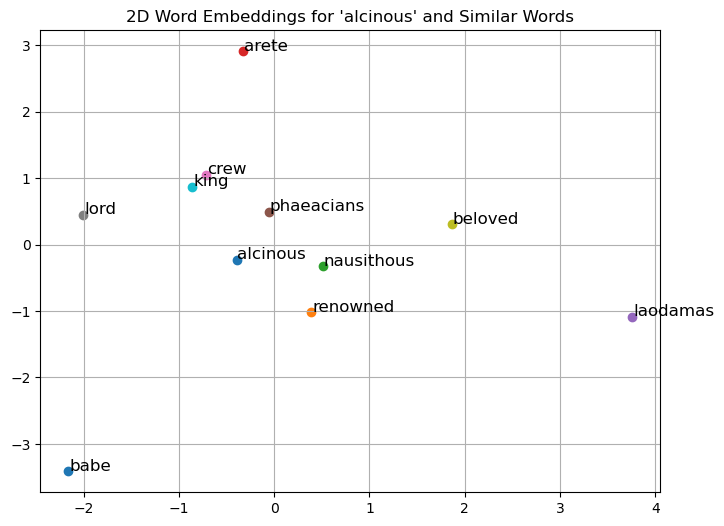

In [10]:
get_ten_closest(skipgram_model, "alcinous") # similar to Alcinous, who hosted Odysseus (a couple positive words can be seen)


target_word = "alcinous"
similar_words = [
    "renowned", "nausithous", "arete", "laodamas", "phaeacians",
    "crew", "lord", "beloved", "king", "babe"
]
all_words = [target_word] + similar_words

word_vectors = [skipgram_model.wv[word] for word in all_words]

pca = PCA(n_components=2)
points_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(8, 6))
for i, word in enumerate(all_words):
    x, y = points_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=12)
plt.title(f"2D Word Embeddings for '{target_word}' and Similar Words")
plt.grid(True)
plt.show()

#2D visual of word embeddings of Alcinous and similar words

In [11]:
get_ten_closest(skipgram_model, "antinous") # similar to Antinous, the worst suitor (a couple negative words can be seen)

Top ten most similar words to  antinous
1. eupeithes, distance: 0.5668290257453918
2. eurymachus, distance: 0.48095154762268066
3. rebuked, distance: 0.48066622018814087
4. unrestrained, distance: 0.44074907898902893
5. swineherd, distance: 0.42770516872406006
6. word, distance: 0.4148396849632263
7. wooer, distance: 0.41141074895858765
8. teeth, distance: 0.4072524905204773
9. insolence, distance: 0.4018537104129791
10. right, distance: 0.39923176169395447


In [12]:
get_ten_closest(skipgram_model, "cyclops") # similar words to cyclops aka Polyphemus (Polyphemus was not a good host, so there's a few negative words)

Top ten most similar words to  cyclops
1. blinded, distance: 0.38881373405456543
2. savage, distance: 0.3777751326560974
3. unrestrained, distance: 0.37609946727752686
4. weakling, distance: 0.36917611956596375
5. kine, distance: 0.3670383095741272
6. soul, distance: 0.3523326516151428
7. daring, distance: 0.3520418405532837
8. seer, distance: 0.34588003158569336
9. shout, distance: 0.3450488746166229
10. violence, distance: 0.34291598200798035


In [13]:
get_ten_closest(skipgram_model, "amphinomus") # similar words to Amphinomus, the only good suitor (even though he is a suitor, some positive words can be seen)

Top ten most similar words to  amphinomus
1. eurymachus, distance: 0.474598228931427
2. spoke, distance: 0.4415834844112396
3. pleasing, distance: 0.4236241579055786
4. fixed, distance: 0.41919323801994324
5. assembly, distance: 0.41649511456489563
6. served, distance: 0.41490569710731506
7. hushed, distance: 0.40396848320961
8. feared, distance: 0.3974849581718445
9. philoetius, distance: 0.3966112434864044
10. seat, distance: 0.39364463090896606


In [14]:
get_ten_closest(skipgram_model, "gift") # similar words to "host", a keyword of hospitality

Top ten most similar words to  gift
1. countless, distance: 0.4210395812988281
2. entertainment, distance: 0.39940303564071655
3. talent, distance: 0.3758123219013214
4. give, distance: 0.3716195821762085
5. friendship, distance: 0.37084630131721497
6. love, distance: 0.36526551842689514
7. booty, distance: 0.36148801445961
8. gracious, distance: 0.3576030135154724
9. promise, distance: 0.3494388163089752
10. home, distance: 0.3487941324710846


In [15]:
get_ten_closest(skipgram_model, "peisistratus") # similar words to "host", a keyword of hospitality

Top ten most similar words to  peisistratus
1. echoing, distance: 0.5622349381446838
2. nestor, distance: 0.5518440008163452
3. car, distance: 0.5457029938697815
4. mounted, distance: 0.5179569721221924
5. portico, distance: 0.51418536901474
6. forehall, distance: 0.49745476245880127
7. whip, distance: 0.4901660084724426
8. inlaid, distance: 0.4871019423007965
9. horse, distance: 0.46691128611564636
10. loath, distance: 0.46656352281570435


In [16]:
'''
returns the analogy based on the pattern: if x1 -> x2, then y1 -> ?
'''

def analogy(x1, x2, y1, model):
  result = model.wv.most_similar(positive=[y1, x2], negative=[x1])
  return result[0][0]

In [17]:
analogy("alcinous", "host", "antinous", skipgram_model) #hospitable character to hospitable word, non-hospitable character to ? (should be a non-hospitable/negative word)

'eupeithes'

In [18]:
analogy("alcinous", "host", "eumaeus", skipgram_model) #hospitable character to hospitable word, another hospitable character to ? (should be a hospitable/positive word)

'flee'

In [19]:
analogy("alcinous", "gift", "eumaeus", skipgram_model) #hospitable character to a different hospitable word, hospitable character to ? (should be a hospitable/positive word)

'foot'

In [20]:
analogy("antinous", "death", "alcinous", skipgram_model) #non-hospitable character to negative word, hospitable character to ? (should be a hospitable/positive word)

'crew'

In [21]:
get_ten_farthest(skipgram_model, "alcinous") # least similar to Alcinous (should be negative words, but these words aren't very relevant)

Top ten least similar words to  alcinous
1. flee, distance: 0.14337211847305298
2. keeping, distance: 0.11893881112337112
3. ti, distance: 0.10913067311048508
4. leaf, distance: 0.1071251779794693
5. onward, distance: 0.09458091109991074
6. dwells, distance: 0.08885876834392548
7. measure, distance: 0.08758676052093506
8. pear, distance: 0.08507157862186432
9. die, distance: 0.0807526707649231
10. noted, distance: 0.0795145109295845


In [22]:
get_ten_farthest(skipgram_model, "menelaus") # least similar to Menelaus (a couple negative words can be seen, cyclops is notable)

Top ten least similar words to  menelaus
1. cheek, distance: 0.13937819004058838
2. cyclops, distance: 0.12523864209651947
3. shape, distance: 0.1134200245141983
4. eaten, distance: 0.09405798465013504
5. tree, distance: 0.09070207178592682
6. large, distance: 0.08592557162046432
7. unless, distance: 0.08364615589380264
8. ear, distance: 0.08187910169363022
9. till, distance: 0.07955200225114822
10. aloud, distance: 0.07940125465393066


In [23]:
get_ten_farthest(skipgram_model, "antinous") # least similar to Antinous (a couple positive words can be seen, which is accurate

Top ten least similar words to  antinous
1. openly, distance: 0.1492501199245453
2. delight, distance: 0.14890176057815552
3. fling, distance: 0.12308084219694138
4. cicones, distance: 0.11105956882238388
5. giver, distance: 0.10597361624240875
6. queenly, distance: 0.09709501266479492
7. olympus, distance: 0.08698917925357819
8. issue, distance: 0.08489793539047241
9. hung, distance: 0.08439609408378601
10. sacred, distance: 0.08329082280397415


In [24]:
get_ten_farthest(skipgram_model, "host") #least similar words to "host" (not very indicative of anything, but a positive word or two can be found)

Top ten least similar words to  host
1. cutting, distance: 0.1374957114458084
2. tree, distance: 0.12361842393875122
3. perforce, distance: 0.11045310646295547
4. sort, distance: 0.10874388366937637
5. blinded, distance: 0.10770781338214874
6. pay, distance: 0.10502111166715622
7. therein, distance: 0.10123564302921295
8. warm, distance: 0.0972445160150528
9. kindled, distance: 0.08983998000621796
10. baneful, distance: 0.08949711918830872


# Computational Method #3: Vocabularies and Distinctive Words

In [25]:
'''
returns the top 10 epithets of a word (usually a character name) from a subset of the text
the subset starts on book #start_book (inclusive) and ends on #end_book (inclusive).
e.g. top_ten_epithets(odysseus, corpus, 1, 24) would return the top 10 epithets of Odysseus across the entire Odyssey (books 1-24, including 1 and 24)
'''

def top_ten_epithets(word, corpus, start_book, end_book):
    totalOd = ""
    s = start_book
    e = end_book
    totalOd += corpus['content'][s-1] + " "
    for i in range(e-s):
        totalOd += corpus["content"][s+i] + " "
    t = totalOd.split()
    dic = {}
    unique = []
    for i in range(len(t)):
        if i == 0:
            pass
        else:
            if t[i] == word.lower():
                key = t[i-1]
                if key in dic:
                    dic[key] += 1
                else:
                    dic[key] = 1
                    unique.append(t[i-1])
    ordered = []
    
    for i in range(len(unique)):
        if len(ordered) == 0:
            ordered.append(unique[i])
           
        else:
            placed = False
            j=0
            while not placed:
                if dic[unique[i]] >= dic[ordered[j]]:
                    ordered.insert(j,unique[i])
                    placed = True
                else:
                    j += 1
                  
                    if j == len(ordered):
                        ordered.append(unique[i])

    
    
    return ordered[:10]


print("The top ten epithets of 'host' are:")
print(top_ten_epithets("host", corpus,1,24))
print("\n")

print("The top ten epithets of 'home' are:")
print(top_ten_epithets("home", corpus,1,24))
print("\n")

print("The top ten epithets of 'feast' are:")
print(top_ten_epithets("feast", corpus,1,24))
print("\n")

print("The top ten epithets of 'gift' are:")
print(top_ten_epithets("gift", corpus,1,24))
print("\n")

print("The top ten epithets of 'menelaus' are:")
print(top_ten_epithets("menelaus", corpus,1,24))
print("\n")

print("The top ten epithets of 'alcinous' are:")
print(top_ten_epithets("alcinous", corpus,1,24))

The top ten epithets of 'host' are:
['leader', 'shepherd', 'whole', 'rouser', 'checked', 'meet', 'amphimedon', 'mighty', 'dustall', 'forth']


The top ten epithets of 'home' are:
['come', 'return', 'reach', 'thy', 'set', 'back', 'go', 'whose', 'reached', 'send']


The top ten epithets of 'feast' are:
['prepare', 'wedding', 'rich', 'glorious', 'ready', 'funeral', 'mar', 'make', 'equal', 'shame']


The top ten epithets of 'gift' are:
['gave', 'glorious', 'many', 'thee', 'took', 'beautiful', 'stranger', 'give', 'goodly', 'offer']


The top ten epithets of 'menelaus' are:
['fairhaired', 'glorious', 'spoke', 'answered', 'came', 'godlike', 'far', 'straightway', 'car', 'gift']


The top ten epithets of 'alcinous' are:
['mighty', 'lord', 'greathearted', 'son', 'wise', 'palace', 'shed', 'said', 'arete', 'king']


In [26]:
'''
returns a list of the 50 most common words in a requested book of the Odyssey, where the first index is the most common word
and the last index is the 50th most common word. 
'''

def top_words_in_a_book(bookNumber, corpus):
    totalBook = corpus['content'][bookNumber-1]
    t = totalBook.split()
    dic = {}
    unique = []
    for i in range(len(t)):
        if t[i] in dic:
            dic[t[i]] += 1
        else:
            dic[t[i]] = 1
            unique.append(t[i])
    ordered = []
    for i in range(len(unique)):
        if len(ordered) == 0:
            ordered.append(unique[i])
            
        else:
            placed = False
            j=0
            while not placed:
                if dic[unique[i]] >= dic[ordered[j]]:
                    ordered.insert(j,unique[i])
                    placed = True
                else:
                    j += 1
                    
                    if j == len(ordered):
                        ordered.append(unique[i])

    return ordered[:50]



In [27]:
top_words_in_a_book(15, corpus) #book 15's fifty most common words

['thy',
 'thee',
 'thou',
 'son',
 'men',
 'house',
 'ship',
 'telemachus',
 'one',
 'go',
 'come',
 'heart',
 'man',
 'forth',
 'answered',
 'spoke',
 'menelaus',
 'came',
 'father',
 'city',
 'odysseus',
 'would',
 'zeus',
 'wise',
 'went',
 'give',
 'land',
 'set',
 'shall',
 'upon',
 'even',
 'tell',
 'good',
 'home',
 'hand',
 'made',
 'may',
 'saying',
 'stranger',
 'brought',
 'took',
 'u',
 'woman',
 'bid',
 'mother',
 'well',
 'nestor',
 'among',
 'verily',
 'dear']

In [28]:
top_words_in_a_book(22, corpus) #book 22's fifty most common words

['odysseus',
 'thou',
 'hall',
 'spoke',
 'thy',
 'wooer',
 'thee',
 'upon',
 'telemachus',
 'come',
 'spear',
 'one',
 'many',
 'many',
 'man',
 'forth',
 'woman',
 'son',
 'hand',
 'door',
 'word',
 'house',
 'might',
 'even',
 'let',
 'bronze',
 'bring',
 'answered',
 'made',
 'foot',
 'dear',
 'long',
 'father',
 'deed',
 'men',
 'may',
 'among',
 'went',
 'way',
 'wellbuilt',
 'arrow',
 'wile',
 'wile',
 'bear',
 'storeroom',
 'wise',
 'swineherd',
 'goodly',
 'body',
 'sword']